# 2 - Healthcare Review Sentiment Classification - Deep Learning

<img src='https://bouve.northeastern.edu/wp-content/uploads/2025/04/iStock-2151920853-1.jpg'>

Bu çalışmada hasta geri bildirimlerindeki duygu etiketlerini tahmin etmek için LSTM tabanlı bir deep learning modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Tokenization ve sequence hazırlama
6. LSTM modeli kurma
7. Tahmin
8. Sonuç


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


## 1. Veriyi Yükleme

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Hospital Reviews Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config', 'drive', 'hospital.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [6]:
# Bu bölümde csv dosyasını okuyup veri setinin genel yapısını inceleyeceğim.

In [7]:
df = pd.read_csv('/content/hospital.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed|^$')]
df.head()


,Feedback,Sentiment Label,Ratings
0,Good and clean hospital. There is great team o...,1,5
1,Had a really bad experience during discharge. ...,1,5
2,I have visited to take my second dose and Proc...,1,4
3,That person was slightly clueless and offered...,1,3
4,There is great team of doctors and good OT fac...,0,1


In [8]:
df.shape


(996, 3)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Feedback         996 non-null    object
 1   Sentiment Label  996 non-null    int64 
 2   Ratings          996 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 23.5+ KB


In [10]:
df['Sentiment Label'].value_counts()


,count
Sentiment Label,
1,728
0,268


## 3. Veri Temizleme

In [11]:
# Bu bölümde boş geri bildirimleri temizleyip metin sütununu string tipine dönüştüreceğim.

In [12]:
df = df.dropna(subset=['Feedback', 'Sentiment Label'])
df['Feedback'] = df['Feedback'].astype(str)
df['Sentiment Label'] = pd.to_numeric(df['Sentiment Label'], errors='coerce')
df = df.dropna(subset=['Sentiment Label'])
df['Sentiment Label'] = df['Sentiment Label'].astype(int)
df.head()


,Feedback,Sentiment Label,Ratings
0,Good and clean hospital. There is great team o...,1,5
1,Had a really bad experience during discharge. ...,1,5
2,I have visited to take my second dose and Proc...,1,4
3,That person was slightly clueless and offered...,1,3
4,There is great team of doctors and good OT fac...,0,1


## 4. Feature Engineering

In [13]:
# Bu bölümde duygu etiketlerini sayısal forma çevirip eğitim ve test verisini ayıracağım.

In [14]:
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['Sentiment Label'])

x_train, x_test, y_train, y_test = train_test_split(
    df['Feedback'],
    df['sentiment_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment_encoded']
)

x_train.shape, x_test.shape


((796,), (200,))

## 5. Tokenization ve Sequence Hazırlama

In [15]:
# Bu bölümde metinleri tokenlara ayırıp LSTM için sabit uzunlukta sequence haline getireceğim.

In [16]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

x_train_pad.shape, x_test_pad.shape


((796, 100), (200, 100))

## 6. LSTM Modeli Kurma

In [17]:
# Bu bölümde Embedding ve Bidirectional LSTM katmanlarını kullanarak deep learning modelini kurup eğiteceğim.

In [18]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train_pad, y_train_cat, epochs=15, batch_size=16, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.7296 - loss: 0.5750 - val_accuracy: 0.7250 - val_loss: 0.5469
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8302 - loss: 0.3709 - val_accuracy: 0.8188 - val_loss: 0.4279
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.9324 - loss: 0.1979 - val_accuracy: 0.8125 - val_loss: 0.5119
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.9701 - loss: 0.1040 - val_accuracy: 0.8625 - val_loss: 0.5230
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9733 - loss: 0.0707 - val_accuracy: 0.8250 - val_loss: 0.6674


## 7. Tahmin

In [19]:
# Bu bölümde test verisi üzerinde tahmin yapıp accuracy ve F1 score ile değerlendireceğim.

In [20]:
y_pred_probs = model.predict(x_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print('Accuracy:', round(accuracy, 4))
print('F1 Score:', round(f1, 4))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
Accuracy: 0.88
F1 Score: 0.8785


In [23]:
print(classification_report(y_test, y_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77        54
           1       0.91      0.93      0.92       146

    accuracy                           0.88       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.88      0.88      0.88       200



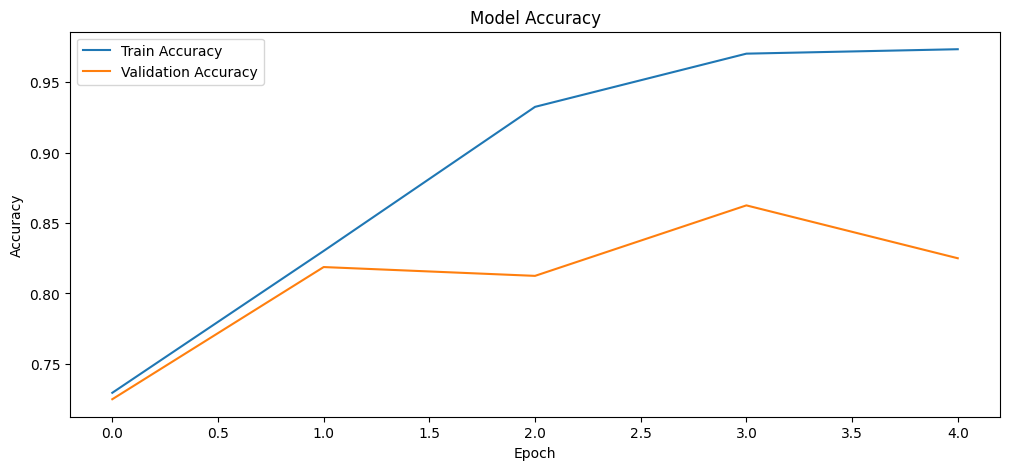

In [24]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 8. Sonuç

Bu projede hasta geri bildirimlerindeki duygu etiketlerini tahmin etmek için LSTM tabanlı bir deep learning modeli kullanıldı. Elde edilen sonuçlara göre model test verisi üzerinde duygu sınıflarını tahmin etti ve 0.88 accuracy ile 0.8785 F1 score değeri elde etti.
